In [23]:
import datetime
import numpy as np
import pandas as pd
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import spearmanr
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib

<p style='font-size:16px'><b> 1) Modelling </b></p>
<p>

- Decision trees are a good option for classification tasks where the target variable depends strongly on combinations & cohorts of multiple features.
- This is relevant for our application as observed during EDA - target variable having high correlation with product, vertical, user_fk_age, etc.
- Thereby we will use RandomForest for this task, additionally a logistic regression was also trained as a base model for comparison.
- Grid search CV was performed for model & hyper parameter tuning.

</p>

<p style='font-size:16px'><b> 2) Metrics </b></p>
<p>

Accuracy score doesn't indicate valuable information when the dataset is heavily imbalanced.

The other metric can be choosed basis business goals, as mentioned below with examples:
- High Recall: Identify & avoid as many fraud orders as possible, even if normal orders are interrupted.
- High Precision: Identify fraud orders with high confidence, there should minimal disruption in normal orders.
- High F1-score: Balance between the two. A high F1-score would be most ideal since it would imply achieving both tasks simultaneously.

For the purpose of this task, the metric choice would be F1-score. Simultaneously other metrics like recall, auc_score will be tracked. <br>
The 'performance_report' function defined below helps in evaluating model performance basis these metrics.

</p>

In [25]:
train_data = pd.read_csv("dataset/train_data.csv")
train_data.drop(['product_id', 'city', 'pincode', 'vertical'], axis = 1, inplace = True)

In [4]:
train_data.dtypes

pid_new          float64
city_new         float64
pincode_new      float64
quantity           int64
selling_price      int64
is_ndd             int64
discount         float64
count_56_days      int64
user_fk_age        int64
cpc_bks          float64
cpc_X4kt         float64
cpc_X4rr         float64
cpc_dep          float64
cpc_kyh          float64
cpc_mgl          float64
cpc_dgv          float64
cpc_ixq          float64
cpc_X26x         float64
cpc_t06          float64
cpc_amz          float64
cpc_reh          float64
cpc_ckf          float64
cpc_j9e          float64
cpc_jek          float64
cpc_tyy          float64
cpc_vdm          float64
cpc_X6bo         float64
cpc_X2oq         float64
cpc_mcr          float64
cpc_osp          float64
cpc_r18          float64
Monday           float64
Tuesday          float64
Wednesday        float64
Thursday         float64
Friday           float64
Saturday         float64
Sunday           float64
vert1            float64
vert2            float64


In [27]:
def performance_report(y_actual, y_predict, y_proba, header):
        
    print('\033[1m' + "\n--------- " + header + " ---------\n" + '\033[0m')
    
    # 1. Overall Accuracy
    acc = accuracy_score(y_actual, y_predict)
    print("1. Overall Accuracy: {}%".format(round(100*acc,1)))

    # 2. Precision
    prec = precision_score(y_actual, y_predict)
    print("2. Precision: {}%".format(round(100*prec,1)))

    # 3. Recall
    rec = recall_score(y_actual, y_predict)
    print("3. Recall: {}%".format(round(100*rec,1)))

    # 4. F1 score
    f1_scr = f1_score(y_actual, y_predict)
    print("4. F1-score: {}%".format(round(100*f1_scr,1)))

    # 5. AUC
    auc_scr = roc_auc_score(y_actual, y_proba)
    print("5. AUC Score: {}%".format(round(100*auc_scr,1)))
    
    print("\n6. Confusion matrix:\n")
    
    cm = confusion_matrix(y_actual, y_predict)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig = plt.figure(figsize = (3,3))
    axs = fig.subplots(1, 1)
    disp.plot(ax = axs, values_format = 'd')


<p style='font-size:16px'><b> 3) Logistic regression </b></p>
<p>

- Performing GridSearchCV for tuning the following hyperparameters: Regularisation parameter, Class weight
- Although the metric choice for cross-validation would be F1-score, other metrics will also be evaluated for each model.

</p>


In [29]:
# Split into X (input) & Y (output)
train_x = train_data.drop('y_label', axis = 1)
train_y = train_data['y_label']

In [41]:
# Standardizing the data - necessary for log-reg modelling
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)

In [43]:
# Model training
start_time = datetime.datetime.now()

logreg_ = LogisticRegression()
hyper_params = {'C': [10**-2, 10**-1, 10**0, 10**1, 10**2], 'class_weight' : [{0:1, 1:1}, {0:1, 1:5}, {0:1, 1:10}, {0:1, 1:100}]}
logreg_gcv = GridSearchCV(logreg_, hyper_params, scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'], refit = 'f1',cv = 5)
logreg_gcv.fit(train_x_scaled, train_y)

print("Training time: ", datetime.datetime.now() - start_time)
print("Hyper param values for best estimator: ", logreg_gcv.best_params_)

Training time:  0:02:11.382800
Hyper param values for best estimator:  {'C': 0.01, 'class_weight': {0: 1, 1: 5}}



--------- Logistic regression: Train data ---------

1. Overall Accuracy: 95.8%
2. Precision: 53.7%
3. Recall: 66.9%
4. F1-score: 59.6%
5. AUC Score: 94.7%

6. Confusion matrix:



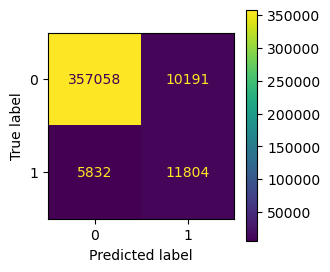

In [45]:
# Performance on training data
y_pred_train = logreg_gcv.best_estimator_.predict(train_x_scaled)
y_proba_train = logreg_gcv.best_estimator_.predict_proba(train_x_scaled)[:,-1]

performance_report(train_y, y_pred_train, y_proba_train, 'Logistic regression: Train data')

In [47]:
logreg_models = pd.DataFrame(logreg_gcv.cv_results_)

logreg_models.loc[:,['param_C', 'param_class_weight', 'mean_test_f1', 'rank_test_f1', 'mean_test_precision', \
                     'rank_test_precision', 'mean_test_recall', 'rank_test_recall']]

,param_C,param_class_weight,mean_test_f1,rank_test_f1,mean_test_precision,rank_test_precision,mean_test_recall,rank_test_recall
0,0.01,"{0: 1, 1: 1}",0.569219,10,0.774118,1,0.450158,20
1,0.01,"{0: 1, 1: 5}",0.594847,1,0.535887,6,0.668405,15
2,0.01,"{0: 1, 1: 10}",0.531081,11,0.407584,11,0.761964,10
3,0.01,"{0: 1, 1: 100}",0.219725,20,0.123957,20,0.966262,2
4,0.1,"{0: 1, 1: 1}",0.570130,9,0.773304,5,0.451576,19
5,0.1,"{0: 1, 1: 5}",0.594812,2,0.535358,7,0.669142,14
6,0.1,"{0: 1, 1: 10}",0.531071,12,0.407443,12,0.762418,9
7,0.1,"{0: 1, 1: 100}",0.219866,18,0.124045,19,0.966319,1
8,1,"{0: 1, 1: 1}",0.570434,8,0.773450,3,0.451916,18
9,1,"{0: 1, 1: 5}",0.594712,3,0.535159,8,0.669199,11


<p style='font-size:16px'><b> 4) Decision tree </b></p>
<p>

Similar to logitic regression:
- Performing GridSearchCV for tuning the following hyperparameters: Max samples (Row sampling ratio), Class weight
- Although the metric choice for cross-validation would be F1-score, other metrics will also be evaluated for each model.

</p>


In [31]:
# Model training
start_time = datetime.datetime.now()

dectree_ = RandomForestClassifier()
hyper_params = {'max_samples': [0.2, 0.4, 0.8], \
                'class_weight' : [{0:1, 1:1}, {0:1, 1:10}, {0:1, 1:100}]}

dectree_gcv = GridSearchCV(dectree_, hyper_params, scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'], refit = 'f1',cv = 5)
dectree_gcv.fit(train_x, train_y)

print("Training time: ", datetime.datetime.now() - start_time)
print("Hyper param values for best estimator: ", dectree_gcv.best_params_)

Training time:  0:22:05.651557
Hyper param values for best estimator:  {'class_weight': {0: 1, 1: 1}, 'max_samples': 0.8}



--------- Random forest with Grid search: Train data ---------

1. Overall Accuracy: 99.9%
2. Precision: 99.4%
3. Recall: 98.2%
4. F1-score: 98.8%
5. AUC Score: 100.0%

6. Confusion matrix:



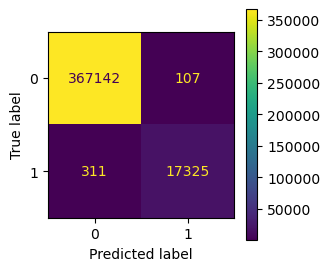

In [55]:
# Performance on training data
y_pred_train = dectree_gcv.best_estimator_.predict(train_x)
y_proba_train = dectree_gcv.best_estimator_.predict_proba(train_x)[:,-1]

performance_report(train_y, y_pred_train, y_proba_train, 'Random forest with Grid search: Train data')

In [57]:
dectree_models = pd.DataFrame(dectree_gcv.cv_results_)

dectree_models.loc[:,['param_max_samples', 'param_class_weight', 'mean_test_f1', 'rank_test_f1', \
                      'mean_test_precision', 'rank_test_precision', 'mean_test_recall', 'rank_test_recall']]

,param_max_samples,param_class_weight,mean_test_f1,rank_test_f1,mean_test_precision,rank_test_precision,mean_test_recall,rank_test_recall
0,0.2,"{0: 1, 1: 1}",0.753560,6,0.912280,3,0.641925,7
1,0.4,"{0: 1, 1: 1}",0.769912,3,0.912485,2,0.665911,4
2,0.8,"{0: 1, 1: 1}",0.785778,1,0.913539,1,0.689385,1
3,0.2,"{0: 1, 1: 10}",0.739175,8,0.906989,4,0.623837,8
4,0.4,"{0: 1, 1: 10}",0.758851,5,0.905452,5,0.653152,5
5,0.8,"{0: 1, 1: 10}",0.773866,2,0.904998,6,0.675947,2
6,0.2,"{0: 1, 1: 100}",0.736213,9,0.901514,7,0.622193,9
7,0.4,"{0: 1, 1: 100}",0.753140,7,0.897453,8,0.648900,6
8,0.8,"{0: 1, 1: 100}",0.765034,4,0.888515,9,0.671751,3


<p style='font-size:16px'><b> 5.1) Model evaluation </b></p>
<p>

- The Decision tree classifier was able to achieve 98.8% F1-Score.
- This probably indicates overfitting, thereby another model with more regularisation needs to be trained.
- We will evaluate the models to identify hyper-parameter values for optimal precision & recall.
- This will be done by plotting the precision, recall & f1-score for each model # defined by corresponding hyper-parameters.

</p>


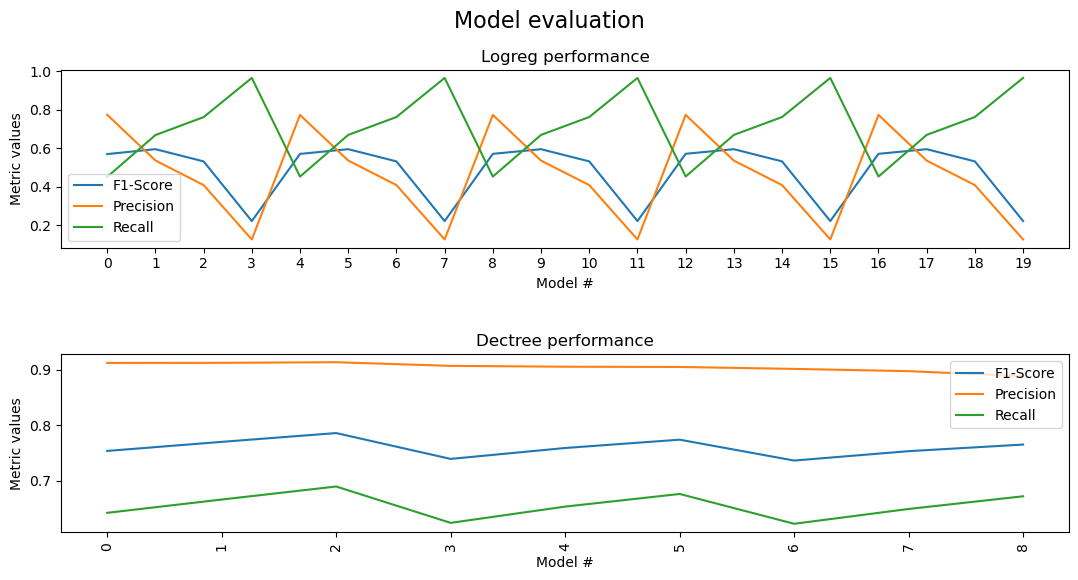

In [49]:
fig = plt.figure(figsize = (13,6))
fig.subplots_adjust(hspace = 0.6)
fig.suptitle('Model evaluation', fontsize = 16) #, y = 0.05)
axs = fig.subplots(2,1)

# For logistic regression model
model_num = np.arange(0,logreg_models.shape[0],1)
axs[0].plot(model_num, logreg_models.loc[:,['mean_test_f1', 'mean_test_precision', 'mean_test_recall']], \
                        # color = ['g', 'b', 'r'], \
                        label = ['F1-Score', 'Precision', 'Recall'])
axs[0].set(xlabel = 'Model #', ylabel = 'Metric values', title = 'Logreg performance')
axs[0].set_xticks(model_num)
axs[0].set_xticklabels(model_num)
axs[0].legend()

# For Decision tree model
model_num = np.arange(0,dectree_models.shape[0],1)
axs[1].plot(model_num, dectree_models.loc[:,['mean_test_f1', 'mean_test_precision', 'mean_test_recall']], \
                        # color = ['g', 'b', 'r'], \
                        label = ['F1-Score', 'Precision', 'Recall'])
axs[1].set(xlabel = 'Model #', ylabel = 'Metric values', title = 'Dectree performance')
axs[1].set_xticks(model_num)
axs[1].set_xticklabels(model_num, rotation = 90)
axs[1].legend()

a = 3 # Ignore

<p style='font-size:16px'><b> 5.2) Inferences </b></p>
<p>

- As expected, there are hyper-parameter values that can maximise precision or recall by compromising the other.
- Thereby, considering above GCV results, new models can be trained based on the target business goal: precison vs recall.
- However, for now focusing on F1-score, we will proceed for adding regularisation in the Random forest by reducing the # of estimators & the row sampling ratio.

</p>


In [72]:
# Training models with hyperparameters optimal for precision & recall each
start_time = datetime.datetime.now()

dectree_reg = RandomForestClassifier(n_estimators = 20, class_weight = {0:1, 1:1}, max_samples = 0.2)
dectree_reg.fit(train_x, train_y)

print("Training time: ", datetime.datetime.now() - start_time)

Training time:  0:00:04.825717



--------- Random forest with Grid search: Train data ---------

1. Overall Accuracy: 98.5%
2. Precision: 95.6%
3. Recall: 70.9%
4. F1-score: 81.4%
5. AUC Score: 99.6%

6. Confusion matrix:



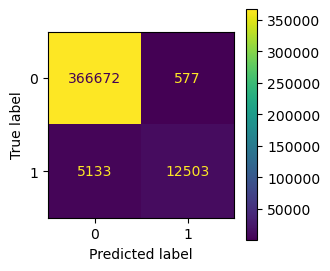

In [74]:
# Performance on training data
y_pred_train = dectree_reg.predict(train_x)
y_proba_train = dectree_reg.predict_proba(train_x)[:,-1]

performance_report(train_y, y_pred_train, y_proba_train, 'Random forest with Grid search: Train data')

<p style='font-size:16px'><b> 6.1) Feature importance & evaluation </b></p>
<p>

Plotting the weights & gini-impurity reduction from logreg & dectree respectively for each feature as a measure to evaluate feature importance.

</p>


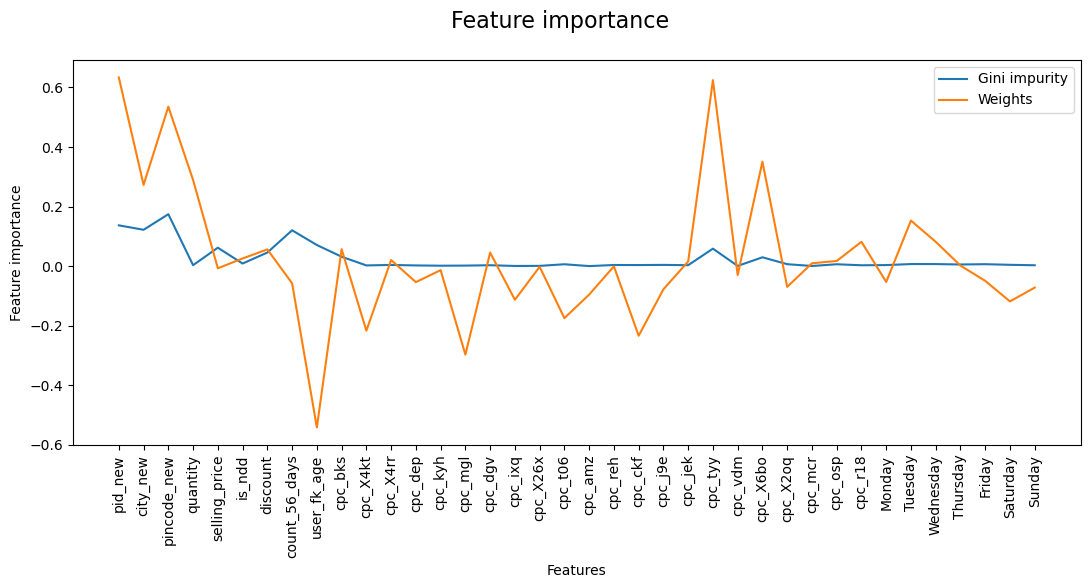

In [51]:
gini_imp = dectree_gcv.best_estimator_.feature_importances_[:38]
weights = logreg_gcv.best_estimator_.coef_.flatten()[:38]

feature_imp = pd.DataFrame({'gini_impurity': gini_imp, 'weights': weights}, index=pd.Index(train_x.columns[:38], name='CustomIndex'))

# Scaling the data so that both values can be seen in the same plot
scaler2 = StandardScaler()
feature_imp_scaled = scaler2.fit_transform(feature_imp)

fig = plt.figure(figsize = (13,5))
fig.suptitle('Feature importance', fontsize = 16) #, y = 0.05)
axs = fig.subplots(1)

feature_num = np.arange(0,train_x.columns[:38].shape[0],1)
axs.plot(feature_num, feature_imp, label = ['Gini impurity', 'Weights'])
axs.set(xlabel = 'Features', ylabel = 'Feature importance')
axs.set_xticks(feature_num)
axs.set_xticklabels(train_x.columns[:38], rotation = 90)
axs.legend()

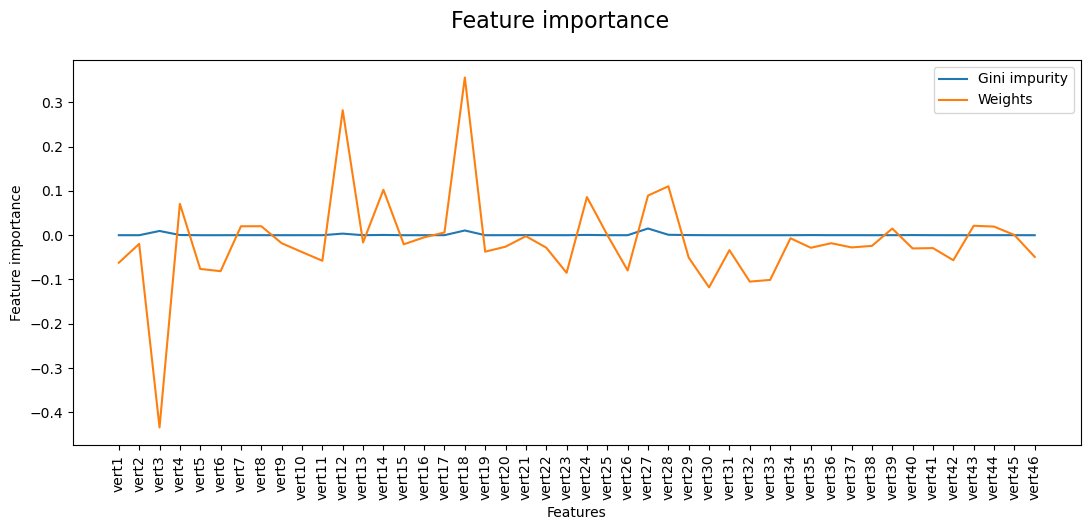

In [53]:
gini_imp = dectree_gcv.best_estimator_.feature_importances_[38:]
weights = logreg_gcv.best_estimator_.coef_.flatten()[38:]

feature_imp = pd.DataFrame({'gini_impurity': gini_imp, 'weights': weights}, index=pd.Index(train_x.columns[38:], name='CustomIndex'))

# Scaling the data so that both values can be seen in the same plot
scaler2 = StandardScaler()
feature_imp_scaled = scaler2.fit_transform(feature_imp)

fig = plt.figure(figsize = (13,5))
fig.suptitle('Feature importance', fontsize = 16) #, y = 0.05)
axs = fig.subplots(1)

feature_num = np.arange(0,train_x.columns[38:].shape[0],1)
axs.plot(feature_num, feature_imp, label = ['Gini impurity', 'Weights'])
axs.set(xlabel = 'Features', ylabel = 'Feature importance')
axs.set_xticks(feature_num)
axs.set_xticklabels(train_x.columns[38:], rotation = 90)
axs.legend()

<p style='font-size:16px'><b> 6.2) Inferences </b></p>
<p>

- As observed during EDA, features having low coeff of variance also indicate low feature importance in the tree.
- Amongst the target encoded features, product_id, pincode has significantly more importance than city. Meaning the fraud orders are more likely to placed on particular products & pincodes.
- user_fk_age, count_56_days, verticals & cpc in some categories are few other important features for classification.

</p>


In [76]:
# GCV Best result (Overfit)
joblib.dump(dectree_gcv.best_estimator_, 'models/dectree_f1.pkl')

# Regularised version
joblib.dump(dectree_reg, 'models/dectree_reg.pkl')

['models/dectree_reg.pkl']